In [1]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten
import numpy as np

from hoda_loader import load_hoda

In [2]:
X_train_original, y_train_original, X_test_original, y_test_original = load_hoda()

In [3]:
X_train_original = X_train_original.reshape(-1, 5, 5)
X_test_original = X_test_original.reshape(-1, 5, 5)

In [4]:
X_train_original.shape

(1000, 5, 5)

In [5]:
X_test_original.shape

(200, 5, 5)

In [6]:
# Preprocessing input data for keras
y_train = y_train_original
y_test = y_test_original

In [7]:
y_train_original[:5]

array([6, 5, 0, 2, 7], dtype=uint8)

In [8]:
y_train[:5]

array([6, 5, 0, 2, 7], dtype=uint8)

In [9]:
# Normalize the data (0 - 1)
X_train = X_train_original.astype('float32')
X_test = X_test_original.astype('float32')
X_train /= 255
X_test /= 255

In [10]:
# Model architecture
model = Sequential()
model.add(Flatten(input_shape=(5, 5)))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

C:\Users\aydin\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 25)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           1,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,314 (9.04 KB)

 Trainable params: 2,314 (9.04 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
import tensorflow as tf

In [13]:
# compile model
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), optimizer='rmsprop', metrics=['accuracy'])

In [14]:
# fitting
history = model.fit(X_train, y_train, epochs=100, batch_size=64, validation_split=0.2)

Epoch 1/100


C:\Users\aydin\AppData\Roaming\Python\Python313\site-packages\keras\src\backend\tensorflow\nn.py:1216: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.1600 - loss: 2.2452 - val_accuracy: 0.3100 - val_loss: 2.1027
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3862 - loss: 2.0098 - val_accuracy: 0.4600 - val_loss: 1.9126
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5250 - loss: 1.8334 - val_accuracy: 0.5900 - val_loss: 1.7409
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6150 - loss: 1.6708 - val_accuracy: 0.6750 - val_loss: 1.5854
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6775 - loss: 1.5192 - val_accuracy: 0.7050 - val_loss: 1.4431
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7237 - loss: 1.3791 - val_accuracy: 0.7150 - val_loss: 1.3061
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7625 - loss: 1.2465 - val_accuracy: 0.7400 - val_loss: 1.1836
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7825 - loss: 1.1253 - val_accuracy: 0.7500 - val_l

In [15]:
import matplotlib.pyplot as plt

Validation accuracy:  0.9100000262260437
Training accuracy:  0.9649999737739563


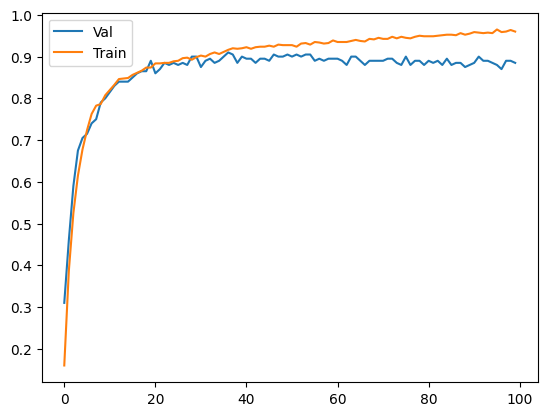

In [23]:
plt.plot(history.history['val_accuracy'])
plt.plot(history.history['accuracy'])
plt.legend(["Val", "Train"]);
print("Validation accuracy: ", max(history.history['val_accuracy']))
print("Training accuracy: ", max(history.history['accuracy']))

In [17]:
# Evaluation model on the test data
loss, acc = model.evaluate(X_test, y_test)
print("\nTesting loss: %.2f, acc: %.2f%%"%(loss, acc))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9100 - loss: 0.2418

Testing loss: 0.24, acc: 0.91%


In [18]:
y_test[1]

np.uint8(2)

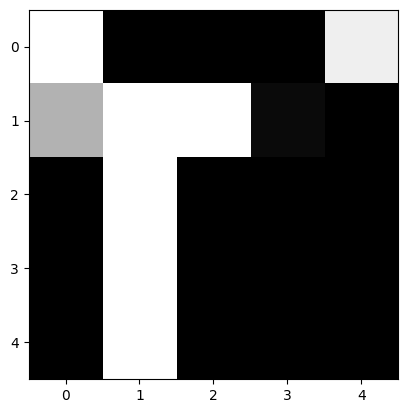

In [19]:
plt.imshow(X_test[1].reshape(5, 5), cmap='gray');

In [20]:
model.predict(X_test)[1].argmax()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


np.int64(2)

In [21]:
model.predict(X_test).max(axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


array([0.9998017 , 0.73423374, 0.87069595, 0.35843018, 0.99396884,
       0.997276  , 0.95569813, 0.9719449 , 0.9705072 , 0.65432155,
       0.61653924, 0.99995303, 0.91969854, 0.9996462 , 0.73778903,
       0.99357235, 0.75339794, 0.99934417, 0.9026019 , 0.97603816,
       0.99853754, 0.9580467 , 0.99271613, 0.8875588 , 0.879865  ,
       0.9622062 , 0.9999529 , 0.99400383, 0.99588984, 0.990807  ,
       0.5221306 , 0.99533516, 0.9465854 , 0.9998832 , 0.99545705,
       0.49613565, 0.99885917, 0.7468019 , 0.98664516, 0.9995459 ,
       0.98006356, 0.946582  , 0.49000493, 0.8136911 , 0.99417853,
       0.9866012 , 0.94276905, 0.9159248 , 0.9930876 , 0.9731944 ,
       0.99187416, 0.65780807, 0.97930473, 0.99922   , 0.74926275,
       0.8774845 , 0.99834335, 0.9830564 , 0.98578274, 0.9981925 ,
       0.98733807, 0.9996673 , 0.9962837 , 0.9991905 , 0.6233342 ,
       0.9928382 , 0.67360103, 0.78670144, 0.6298887 , 0.93564475,
       0.6483556 , 0.99986935, 0.95172936, 0.9770885 , 0.97992

In [22]:
accuracy = np.mean(model.predict(X_test).argmax(axis=1) == y_test)
print(accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
0.91
